In [104]:
import requests
import matplotlib.pyplot as plt
import numpy as np

In [105]:
# url = "http://127.0.0.1:8000/",
url = "https://gd-secret-api.onrender.com/"

evaluate_url = url + "evaluate"
evaluate_with_grad_url = url + "evaluate-with-gradient"
discovery_url = url + "problems"


In [106]:

def _is_json_like(obj):
    return isinstance(obj, (dict, list))


def test_evaluate_default_x_returns_json():
    resp = requests.post(
        evaluate_url,
        json={"problem_id": "parabola_1d", "x": [2.5]},
    )
    assert resp.status_code == 200
    data = resp.json()
    assert _is_json_like(data)


def test_evaluate_parabola_1d_returns_json():
    resp = requests.post(
        evaluate_url,
        json={
            "problem_id": "parabola_1d",
            "x": [2.5]
        },
    )
    assert resp.status_code == 200
    data = resp.json()
    assert _is_json_like(data)


In [107]:
def evaluate_1d(x):
    if isinstance(x, (int, float)):
        x = [x]
    if isinstance(x, np.ndarray):
        x = x.tolist()
    resp = requests.post(
        evaluate_url,
        json={
            "problem_id": "parabola_1d",
            "x": x
        },
    )
    assert resp.status_code == 200
    data = resp.json()
    assert _is_json_like(data)
    return data["y"]


def evaluate_1d_calc_grad(x, eps=1e-6):
    if isinstance(x, (int, float)):
        x = np.array([x])
    x_plus_eps = (x + eps).tolist()
    x_minus_eps = (x - eps).tolist()
    # convert x_plus_eps and x_minus_eps to lists for the API
    y_plus = evaluate_1d(x_plus_eps)
    y_minus = evaluate_1d(x_minus_eps)
    y = evaluate_1d(x.tolist())
    grad = (y_plus - y_minus) / (2 * eps)
    return y, grad


def evaluate_2d(x_vec):
    """Evaluate a 2D problem by POSTing to the evaluate endpoint."""
    resp = requests.post(
        evaluate_url,
        json={
            "problem_id": "bowl_2d",
            "x": x_vec,
        },
    )
    assert resp.status_code == 200
    data = resp.json()
    assert _is_json_like(data)
    return data["y"]

def evaluate_calc_grad(x_vec, api_func, eps=1e-6):
    """Compute numerical gradient for a 2D input using central differences."""
    # ensure we have a mutable copy
    grad = np.zeros_like(x_vec)
    for i in range(x_vec.shape[0]):
        x_plus = list(x_vec)
        x_minus = list(x_vec)
        x_plus[i] += eps
        x_minus[i] -= eps
        y_plus = api_func(x_plus)
        y_minus = api_func(x_minus)
        grad[i] = (y_plus - y_minus) / (2 * eps)
    y = api_func(x_vec)
    return y, grad

# print(evaluate_1d(2.5))
# print(evaluate_1d_calc_grad(2.5))
# print(evaluate_2d([10.0, -3.0]))
# print(evaluate_2d_calc_grad([10.0, -3.0]))

In [ ]:
curr_diff = np.inf
curr_x = np.array([np.random.rand() * 10])
step_size = 0.01


print(f"Initial x: {curr_x}")
print(f"Initial y: {evaluate_1d(curr_x)}")
print(f"Step size: {step_size}")

y_values = []
grad_sizes = []

while curr_diff > 1e-5:
    # y, grad = evaluate_1d_calc_grad(curr_x)
    y, grad = evaluate_calc_grad(curr_x, evaluate_1d)
    y_values.append(y)
    grad = np.array(grad)
    grad_sizes.append(np.linalg.norm(grad))
    print(f"x: {curr_x}, y: {y}, grad: {grad}")
    next_x = curr_x - step_size * grad
    curr_diff = abs(next_x - curr_x)
    curr_x = next_x

print(f"Final x: {curr_x}, Final y: {evaluate_1d(curr_x)}")

Initial x: [4.864411]
Initial y: 3.4760283750585645
Step size: 0.01
x: [4.864411], y: 3.4760283750585645, grad: [3.728822]
x: [4.82712278], y: 3.3383776513837864, grad: [3.65424556]
x: [4.79058032], y: 3.2061778963720675, grad: [3.58116065]
x: [4.75476872], y: 3.0792132516529174, grad: [3.50953744]
x: [4.71967334], y: 2.9572764068632686, grad: [3.43934669]
x: [4.68527988], y: 2.840168261137204, grad: [3.37055975]
x: [4.65157428], y: 2.727697597981297, grad: [3.30314856]
x: [4.61854279], y: 2.619680773087093, grad: [3.23708559]
x: [4.58617194], y: 2.5159414144570094, grad: [3.17234387]
x: [4.5544485], y: 2.416310134430099, grad: [3.108897]
x: [4.52335953], y: 2.320624253093489, grad: [3.04671906]
x: [4.49289234], y: 2.228727532656879, grad: [2.98578468]
x: [4.46303449], y: 2.140469922348282, grad: [2.92606898]
x: [4.4337738], y: 2.055707313407449, grad: [2.8675476]
x: [4.40509833], y: 1.9743013037833608, grad: [2.81019665]
x: [4.37699636], y: 1.8961189721416278, grad: [2.75399272]
x: [4

Text(0, 0.5, 'y value')

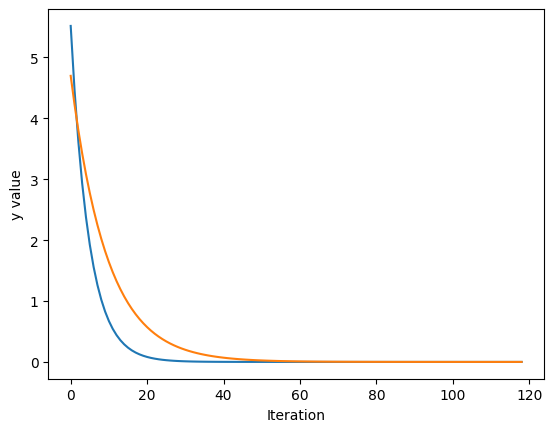

In [ ]:
# plot y_values over time
plt.plot(y_values)
plt.plot(grad_sizes)
plt.xlabel("Iteration")
plt.ylabel("y value") 